# All Arecibo Sky Plots

Plot both the grids, and the ALFALFA100 [Haynes et al. 2018](http://adsabs.harvard.edu/abs/2018ApJ...861...49H) sources.

In [1]:
#Import statements

import pandas as pd
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle

from astropy import wcs

from regions import RectangleSkyRegion
import numpy as np

import matplotlib.pyplot as plt

from astroquery.vizier import Vizier

In [2]:
#Defining some functions

def makegridwcs(sky_center):
    w = wcs.WCS(naxis=2)
    w.wcs.crpix = [float(sky_center.ra/u.deg)+1, float(sky_center.dec/u.deg)+1]
    #Adding one makes pixel values identical to RA and Dec
    w.wcs.cdelt = [1.0,1.0]
    w.wcs.crval = [float(sky_center.ra/u.deg), float(sky_center.dec/u.deg)]
    w.wcs.ctype = ["RA---CAR", "DEC--CAR"]
    return w

def plotgrid(i):
    sky_region = grids["box"][i]
    sky_center = grids["coord"][i]
    w = makegridwcs(sky_center)            
    pixel_region = sky_region.to_pixel(w)
    pixel_region.plot(ax=ax, color='red', lw=1.0)

In [3]:
#Opening the list of grids, and putting it into a Pandas database

with open("gridlist_july2025.txt", "r") as f:
    grids = f.read().split()

grids = pd.DataFrame({"gridname": grids})
grids["coord"] = grids.gridname.map(lambda x: SkyCoord(x[0:2] + ":" + x[2:], unit=(u.hourangle, u.deg)))
grids["box"]   = grids.coord.map(lambda x:RectangleSkyRegion(x, width=2.4*u.deg, height = 2.4*u.deg))

grids["ra"] = grids["coord"].map(lambda x: round(float(x.ra/u.deg)))
grids["dec"] = grids["coord"].map(lambda x: round(float(x.dec/u.deg)))

In [4]:
#Download the ALFALFA 100% from Vizier/CDS
cat = Vizier(catalog="J/ApJ/861/49/table2", columns=['*', '_RAJ2000', '_DEJ2000'], row_limit=-1).query_constraints()[0]

In [5]:
cat

_RAJ2000,_DEJ2000,AGC,Name,RAJ2000,DEJ2000,RAO,DEO,Vhel,W50,e_W50,W20,HIflux,e_HIflux,SNR,rms,Dist,e_Dist,logMHI,e_logMHI,HI,sp,fits,Simbad,NED,LEDA
deg,deg,,,,,,,km / s,km / s,km / s,km / s,Jy km / s,Jy km / s,,mJy,Mpc,Mpc,log(solMass),log(solMass),,,,,,
float64,float64,str6,str8,str10,str9,str10,str9,int16,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,uint8,str2,str4,str6,str3,str4
0.001667,5.443333,105367,,00 00 00.4,+05 26 36,00 00 00.8,+05 26 33,11983,274,39,281,1.14,0.08,8.1,1.91,166.0,2.3,9.87,0.05,1,sp,fits,Simbad,NED,LEDA
0.003750,24.908889,333313,,00 00 00.9,+24 54 32,23 59 59.4,+24 54 27,11181,313,20,333,1.80,0.09,11.3,2.02,154.8,2.3,10.01,0.05,1,sp,fits,Simbad,NED,LEDA
0.010417,23.084722,331060,478-009b,00 00 02.5,+23 05 05,00 00 03.4,+23 05 15,4463,160,4,184,1.96,0.07,14.7,2.35,50.6,10.4,9.07,0.18,1,sp,fits,Simbad,NED,LEDA
0.010417,15.872222,331061,456-013,00 00 02.5,+15 52 20,00 00 02.1,+15 52 54,6007,260,45,268,1.13,0.09,6.5,2.40,85.2,2.4,9.29,0.06,1,sp,fits,Simbad,NED,LEDA
0.006667,32.708333,104570,,00 00 01.6,+32 42 30,00 00 01.2,+32 42 37,10614,245,6,250,0.86,0.07,6.6,1.86,147.0,2.3,9.64,0.06,1,sp,fits,Simbad,NED,LEDA
0.013750,26.016389,331405,,00 00 03.3,+26 00 59,00 00 03.5,+26 00 50,10409,315,8,345,2.62,0.09,16.1,2.05,143.8,2.2,10.11,0.05,1,sp,fits,Simbad,NED,LEDA
0.028333,28.201944,102896,,00 00 06.8,+28 12 07,00 00 06.0,+28 12 07,16254,406,17,433,2.37,0.12,11.2,2.31,227.4,2.2,10.46,0.05,1,sp,fits,Simbad,NED,LEDA
0.031250,-0.046944,630358,382-015,00 00 07.5,-00 02 49,00 00 07.8,-00 02 26,7089,70,9,103,2.47,0.06,29.7,2.20,96.2,2.3,9.73,0.05,1,sp,fits,Simbad,NED,LEDA


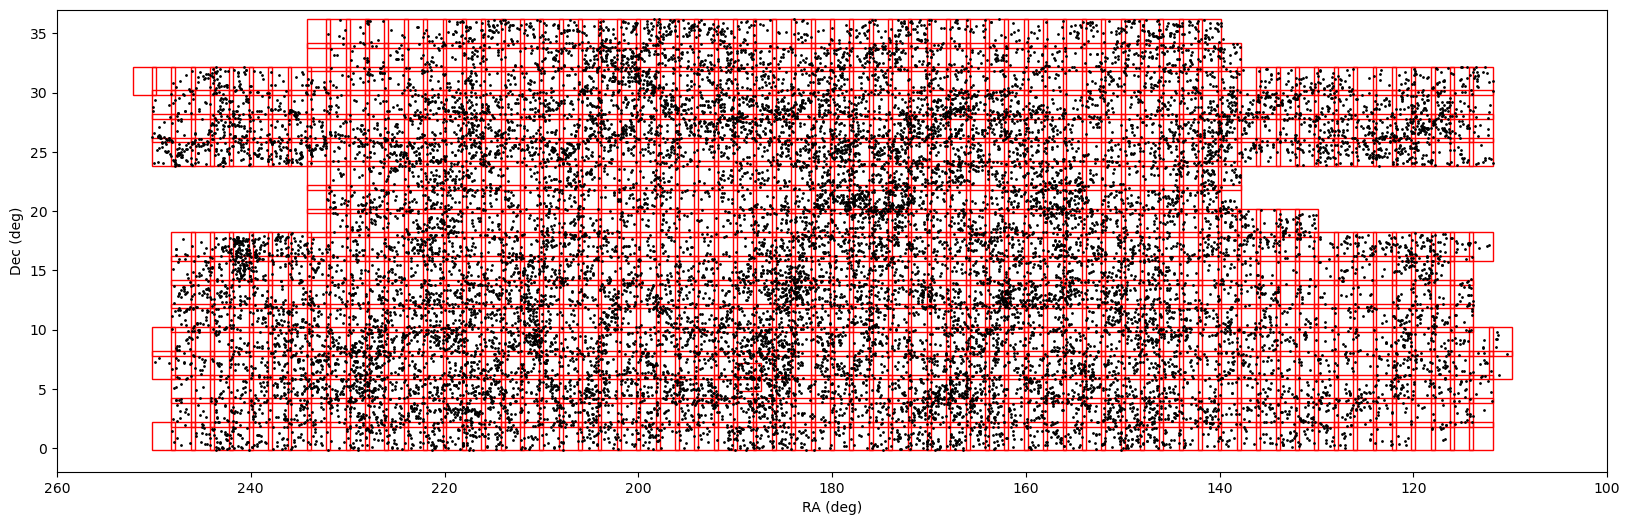

In [6]:
#Plot the ALFALFA Spring Sky (RA = 07h30m to 16h30m or 112.5-247.5deg)

fig, ax = plt.subplots(figsize=(20,6))
plt.xlim(260,100)
plt.ylim(-2,37)
plt.plot(cat["_RAJ2000"],cat["_DEJ2000"],'ko', markersize=1)
plt.ylabel('Dec (deg)') 
plt.xlabel('RA (deg)')

for i in range(len(grids)): plotgrid(i)

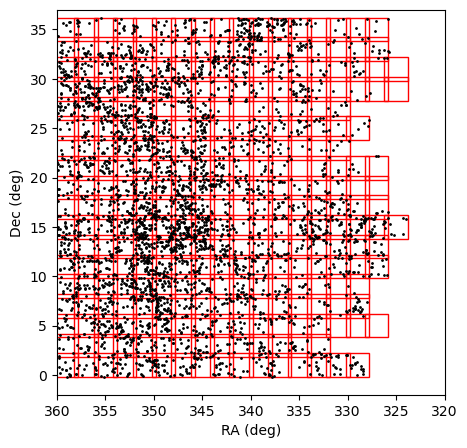

In [7]:
#Plot one half of the Fall sky
fig, ax = plt.subplots(figsize=(5,5))

plt.xlim(360, 320)
plt.plot(cat["_RAJ2000"],cat["_DEJ2000"],'ko', markersize=1)
plt.ylim(-2,37)
plt.ylabel('Dec (deg)') 
plt.xlabel('RA (deg)')

for i in range(len(grids)): plotgrid(i)

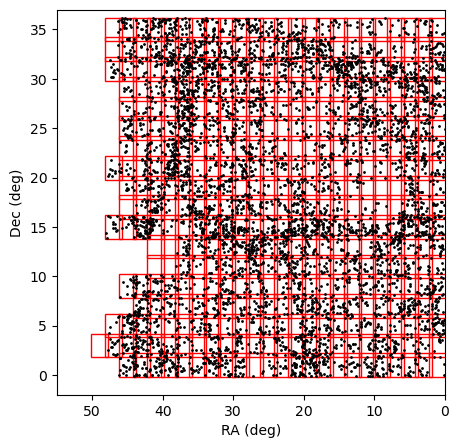

In [8]:
#Plot the other half of the Fall sky
fig, ax = plt.subplots(figsize=(5,5))

plt.xlim(55, 0)
plt.plot(cat["_RAJ2000"],cat["_DEJ2000"],'ko', markersize=1)
plt.ylim(-2,37)
plt.ylabel('Dec (deg)') 
plt.xlabel('RA (deg)')

for i in range(len(grids)): plotgrid(i)

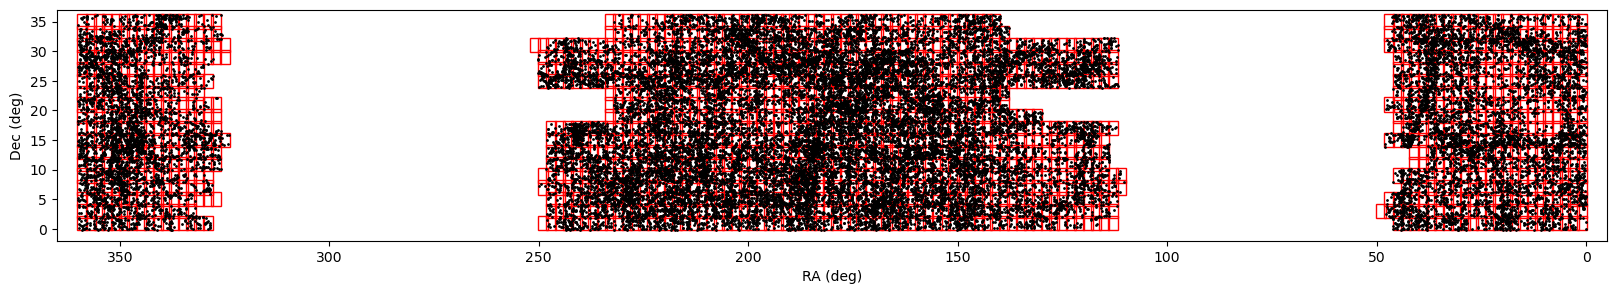

In [9]:
# Plot the entire sky: 

fig, ax = plt.subplots(figsize=(20,3))
plt.xlim(365, -5)
plt.plot(cat["_RAJ2000"],cat["_DEJ2000"],'ko', markersize=1)
plt.ylim(-2,37)
plt.ylabel('Dec (deg)') 
plt.xlabel('RA (deg)')

for i in range(len(grids)): plotgrid(i)